In [75]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("emmarex/plantdisease")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\asus\.cache\kagglehub\datasets\emmarex\plantdisease\versions\1


In [130]:
# Check dataset structure
import os
print("Dataset path:", path)
print("\nContents of dataset directory:")
items = os.listdir(path)
for item in items[:20]:  # Show first 20 items
    item_path = os.path.join(path, item)
    if os.path.isdir(item_path):
        # Count images in subdirectory
        files = os.listdir(item_path)
        img_count = len([f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))])
        print(f"   {item}/ - {img_count} images, {len(files)} total files")
    else:
        print(f"   {item}")


Dataset path: C:\Users\asus\.cache\kagglehub\datasets\emmarex\plantdisease\versions\1

Contents of dataset directory:
   PlantVillage/ - 0 images, 16 total files


In [77]:
import tensorflow as tf
from tensorflow.keras import layers,  models 
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense,Conv2D, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from tensorflow.keras.utils import to_categorical
from keras.applications.vgg16 import VGG16
from keras.layers import InputLayer , GlobalAveragePooling2D
import matplotlib.pyplot as plt


In [ ]:
# Load plant disease dataset
import os
import numpy as np
from PIL import Image

IMG_SIZE = 224

# Path to PlantVillage directory
data_path = os.path.join(path, 'PlantVillage')

# Load images from directory
def load_images_from_dir(directory, img_size=IMG_SIZE):
    images = []
    labels = []
#    
    # Get class directories
    classes = sorted([d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))])
    class_dict = {cls: idx for idx, cls in enumerate(classes)}
    
    print(f"Found {len(classes)} classes: {classes}")
    
    for class_name in classes:
        class_path = os.path.join(directory, class_name)
        image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        print(f"  {class_name}: {len(image_files)} images")
        
        # Load up to 500 images per class
        for img_file in image_files[:500]:
            try:
                img_path = os.path.join(class_path, img_file)
                img = Image.open(img_path).convert('RGB').resize((img_size, img_size))
                images.append(np.array(img))
                labels.append(class_dict[class_name])
            except:
                pass
    
    return np.array(images), np.array(labels), len(classes)

# Load all data
data, labels, num_classes = load_images_from_dir(data_path)

# Split into train and test (80-20)
np.random.seed(42)
indices = np.random.permutation(len(data))
split_idx = int(len(data) * 0.8)
train_indices = indices[:split_idx]
test_indices = indices[split_idx:]

x_train = data[train_indices]
y_train = labels[train_indices]
x_test = data[test_indices]
y_test = labels[test_indices]

print(f"\nLoaded {len(data)} total images")
print(f"Training set: {x_train.shape}")
print(f"Test set: {x_test.shape}")


Found 16 classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'PlantVillage', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
  Pepper__bell___Bacterial_spot: 997 images
  Pepper__bell___healthy: 1478 images
  PlantVillage: 0 images
  Potato___Early_blight: 1000 images
  Potato___Late_blight: 1000 images
  Potato___healthy: 152 images
  Tomato_Bacterial_spot: 2127 images
  Tomato_Early_blight: 1000 images
  Tomato_Late_blight: 1909 images
  Tomato_Leaf_Mold: 952 images
  Tomato_Septoria_leaf_spot: 1771 images
  Tomato_Spider_mites_Two_spotted_spider_mite: 1676 images
  Tomato__Target_Spot: 1404 images
  Tomato__Tomato_YellowLeaf__Curl_Virus: 3208 images
  Tomato__Tomato_mosai

In [114]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)


(5620, 224, 224, 3)
(5620,)
(1405, 224, 224, 3)
(1405,)


In [115]:
#Convert class vectors to binary class matrices (One hot encoding)
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)


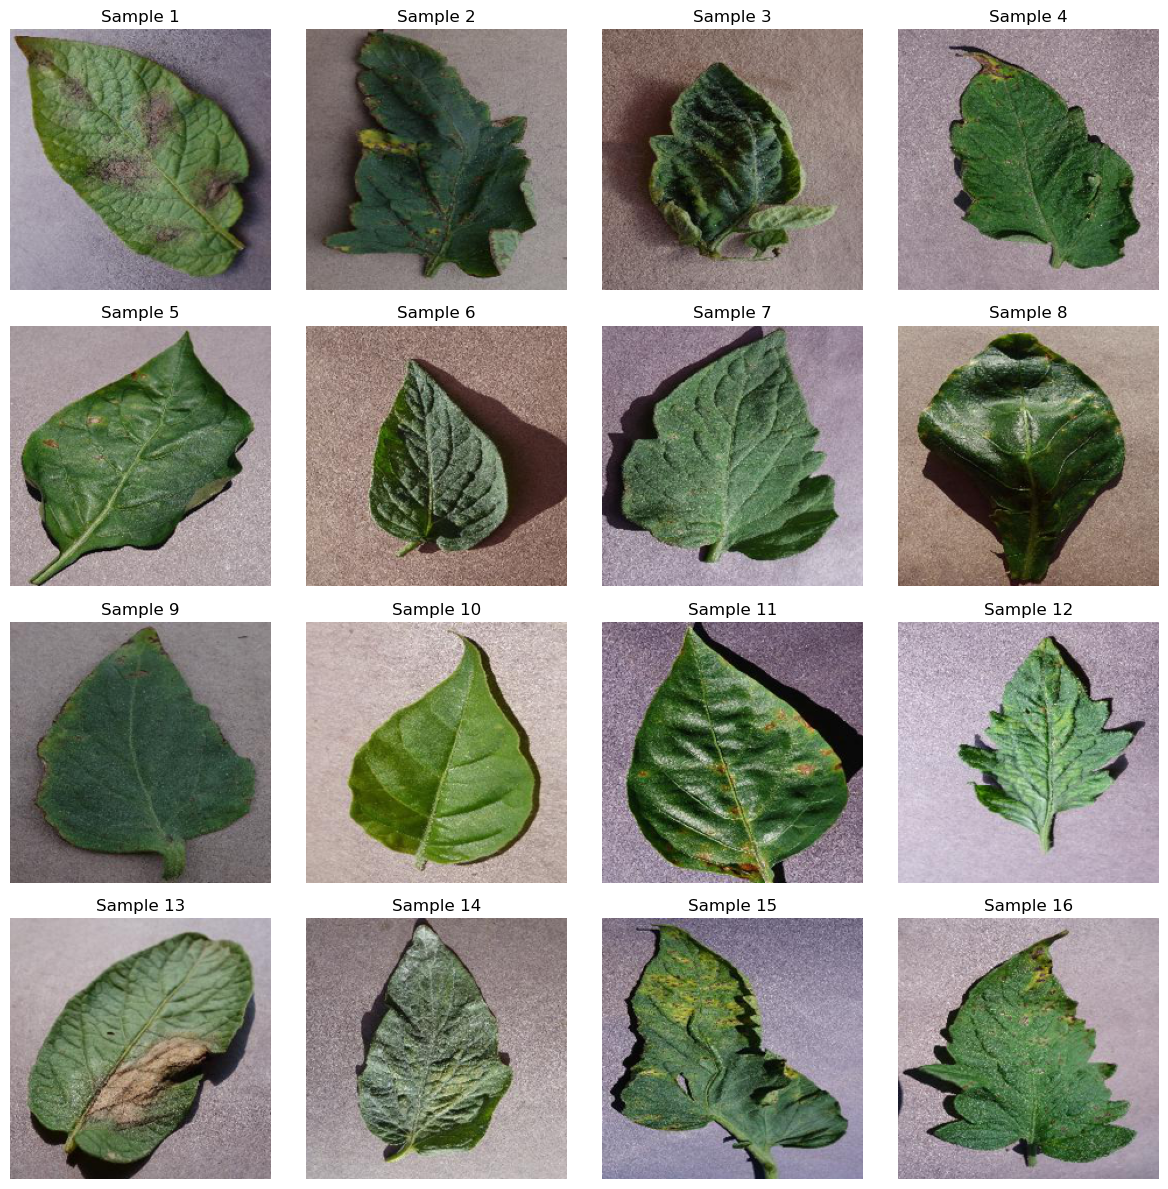

In [131]:
# Visualize sample images from the dataset
import matplotlib.pyplot as plt
import numpy as np

# Create a figure and subplots
fig, axes = plt.subplots(4, 4, figsize=(12, 12))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Get random indices
random_indices = np.random.choice(x_train.shape[0], 16, replace=False)

for i, ax in enumerate(axes):
    image = x_train[random_indices[i]].astype(np.uint8)  # No denormalization needed
    ax.imshow(image)
    ax.set_title(f"Sample {i+1}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [125]:
base_model=VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

In [126]:
#Freeze the layers of VGG16
for layer in base_model.layers:
    layer.trainable=False

In [119]:
#Build the model
model = Sequential()

#Define the input shape
model.add(InputLayer(input_shape=(IMG_SIZE, IMG_SIZE, 3)))

#Add the VGG16 base model
model.add(base_model)

#Flatten/pool the output from VGGi16's convolutional layers
#model.add(Flatten()) use when dataset is large.preserves spatial information
model.add(GlobalAveragePooling2D())

#Add a fully connected layer with 256 units and ReLU activation 
model.add(Dense(256, activation='relu'))

#Add a dropout layer with a rate of 0.3 to prevent overfitting
model.add(Dropout(0.3))

#Add the output layer with 10 units (for 10 classes) and softmax activation
model.add(Dense(num_classes, activation='softmax'))

#Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

#print the model summary 
model.summary()



Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, None, None, 512)   14714688  
                                                                 
 global_average_pooling2d_7  (None, 512)               0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_14 (Dense)            (None, 256)               131328    
                                                                 
 dropout_7 (Dropout)         (None, 256)               0         
                                                                 
 dense_15 (Dense)            (None, 16)                4112      
                                                                 
Total params: 14850128 (56.65 MB)
Trainable params: 135440 (529.06 KB)
Non-trainable params: 14714688 (56.13 MB)
_______

In [120]:
# Training data generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

# Validation/Test generator (only rescale - NO augmentation)
val_test_datagen = ImageDataGenerator(rescale=1./255)

In [121]:
# Create data generators
batch_size = 64
epochs = 3

train_generator = train_datagen.flow(
    x_train, y_train, 
    batch_size=batch_size, 
    shuffle=True
)

val_generator = val_test_datagen.flow(
    x_test, y_test, 
    batch_size=batch_size, 
    shuffle=False
)

In [122]:
# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=x_train.shape[0] // batch_size, 
    epochs=epochs, 
    validation_data=val_generator,
    validation_steps=x_test.shape[0] // batch_size
)

Epoch 1/3
87/87 [==============================] - 342s 4s/step - loss: 2.3358 - accuracy: 0.2792 - val_loss: 1.9429 - val_accuracy: 0.4382
Epoch 2/3
87/87 [==============================] - 333s 4s/step - loss: 1.7057 - accuracy: 0.4993 - val_loss: 1.4629 - val_accuracy: 0.5848
Epoch 3/3
87/87 [==============================] - 332s 4s/step - loss: 1.3797 - accuracy: 0.5860 - val_loss: 1.2097 - val_accuracy: 0.6458


In [128]:
# Evaluate the model using generator (properly normalized)
test_generator = val_test_datagen.flow(
    x_test, y_test,
    batch_size=batch_size,
    shuffle=False
)

test_loss, test_acc = model.evaluate(test_generator, steps=x_test.shape[0] // batch_size, verbose=1)
print(f'Test accuracy: {test_acc:.4f}')

21/21 [==============================] - 65s 3s/step - loss: 1.2097 - accuracy: 0.6458
Test accuracy: 0.6458


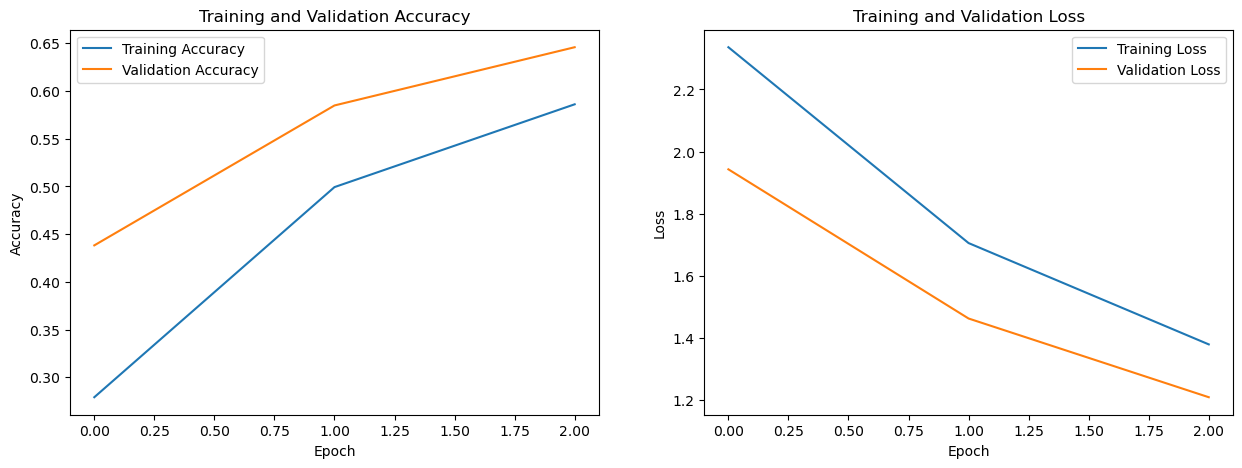

In [129]:
#plot training and validation accuracy and loss
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
